In [63]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.optimizers import Adam

In [64]:
# Fake Dataset
def gen_data(m, degree, noise=0.5):
    X = np.linspace(0, 10, m)
    y = X**degree + np.random.randn(m) * noise
    return X.reshape(-1, 1), y

In [65]:
X, y = gen_data(40, 2, 2)

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=1)
X_cv, X_test, y_cv, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=1)

In [66]:
def eval_mse(y, yhat):
    m = len(y)
    return np.sum((y - yhat)**2)/(2*m)

# 👉 Measures how wrong your predictions are

# Small → good model
# Large → bad model

In [67]:
def train_poly_model(X, y, degree, lambda_=0):
    poly = PolynomialFeatures(degree)
    X_poly = poly.fit_transform(X)

    if lambda_ == 0:
        model = LinearRegression()
    else:
        model = Ridge(alpha = lambda_)

    model.fit(X_poly, y)
    return model, poly

# Step-by-step:
# PolynomialFeatures
# converts:
# x → [1, x, x², x³...]

# Choose model:
# No regularization → LinearRegression
# With λ → Ridge

# Train model (fit)

In [68]:
max_degree = 10
train_error = []
cv_error = []

for d in range(1, 1 + max_degree):
    model, poly = train_poly_model(X_train, y_train, d)
    
    y_train_pred = model.predict(poly.transform(X_train))
    y_cv_pred = model.predict(poly.transform(X_cv))

    train_error.append(eval_mse(y_train, y_train_pred))
    cv_error.append(eval_mse(y_cv, y_cv_pred))

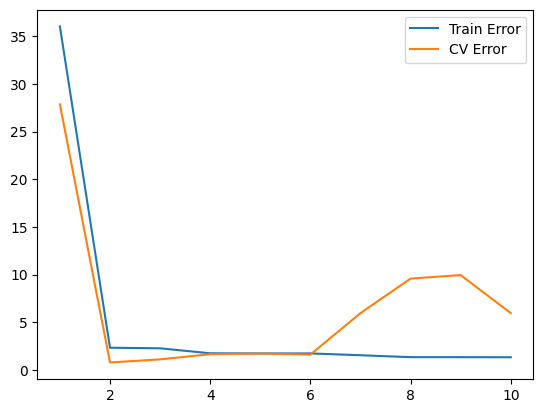

In [69]:
plt.plot(range(1, max_degree + 1), train_error, label="Train Error")
plt.plot(range(1, max_degree + 1), cv_error, label="CV Error")
plt.legend()
plt.show()

# Interpretation:
# Train error ↓ always decreases
# CV error:
# ↓ first → better model
# ↑ later → overfitting

# 👉 Optimal degree = lowest CV error

In [70]:
lambda_values = [0, 0.01, 0.1, 1, 10, 100] #compute and choose hyperparameter lamba values based on cv
train_error = []
cv_error = []

degree = 5

for lam in lamba_values:
    model, poly = train_poly_model(X_train, y_train, degree, lam)

    y_train_pred = model.predict(poly.transform(X_train))
    y_cv_pred = model.predict(poly.transform(X_cv))

    train_error.append(eval_mse(y_train, y_train_pred))
    cv_error.append(eval_mse(y_cv, y_cv_pred))

# What’s happening:

# Now fixing degree, tuning λ (lambda)

# 👉 λ controls:

# 0 → overfitting
# large → underfitting

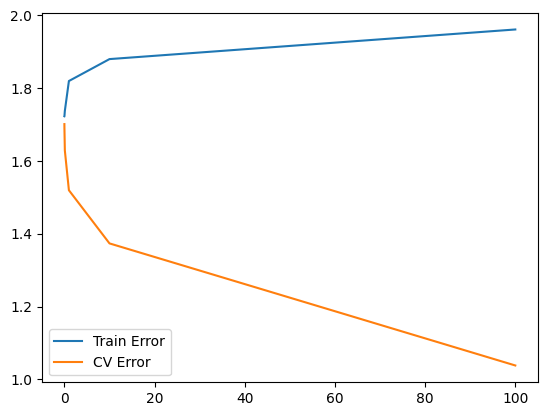

In [71]:
plt.plot(lambda_values, train_error, label="Train Error")
plt.plot(lambda_values, cv_error, label="CV Error")
plt.legend()
plt.show()

In [72]:
def eval_cat_err(y, yhat):
    return np.mean(y != yhat)

In [73]:
X, y = make_blobs(n_samples=500, centers=6, random_state=1)

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4)
X_cv, X_test, y_cv, y_test = train_test_split(X_temp, y_temp, test_size=0.5)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_cv = scaler.transform(X_cv)
X_test = scaler.transform(X_test)

In [74]:
model = Sequential([
    Dense(units=120, activation='relu'),
    Dense(units=40, activation='relu'),
    Dense(units=6, activation='linear')
])

In [75]:
model.compile(
    loss = SparseCategoricalCrossentropy(from_logits=True),
    optimizer = Adam(learning_rate=0.001)
)

In [76]:
model.fit(X_train, y_train, epochs=200, verbose=0)

In [77]:
logits = model.predict(X_cv)
y_pred = np.argmax(logits, axis=1)

1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/stepWARNING:tensorflow:6 out of the last 12 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x12ea22a20> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


In [78]:
error = eval_cat_err(y_cv, y_pred)
print("Classification Error:", error)

Classification Error: 0.12


In [79]:
# 🎯 Debug mindset (VERY IMPORTANT)

# Whenever you see bad performance:

# 1. Check data (labels correct?)
# 2. Check scaling
# 3. Check learning rate
# 4. Check training time

# 👉 This is exactly what we did here

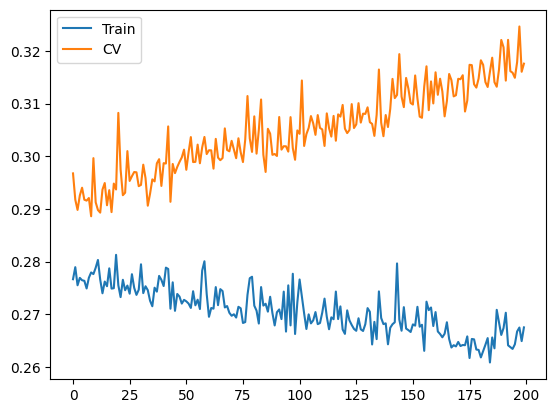

In [80]:
history = model.fit(
    X_train, y_train,
    epochs=200,
    validation_data=(X_cv, y_cv),
    verbose=0
)

plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='CV')
plt.legend()
plt.show()